In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

'''
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nimport os\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

# Importing necessary libraries

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import requests
import re

# MODEL ARCHITECTURE

In [26]:
# MODEL DEFINITION 
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=128):
        super().__init__()
        # Char IDs → dense embeddings
        self.embedding = nn.Embedding(vocab_size, embed_size) # char ID → 64-dim vector
        # GRU processes temporal dependencies
        self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True) # processes sequence
        # Hidden states → vocabulary logits
        self.fc = nn.Linear(hidden_size, vocab_size) # hidden → vocab logits

    # forward pass
    def forward(self, x):
        x = self.embedding(x) # (batch, seq, embed_size) - [32, 32, 64]
        out, _ = self.rnn(x)  # (batch, seq, hidden_size) - [32, 32, 128] (output at each timestep)
        return self.fc(out)   # (batch, seq, vocab_size) - [32, 32, 12] (logits for each position)

# TRAINING SETUP

# Helper Functions

In [37]:
# Encoding helper: text → tensor of character indices
def encode(t, char_to_ix): 
    return torch.tensor([char_to_ix[c] for c in t], dtype=torch.long)

# Build sliding windows: input sequences and shifted targets (teacher forcing)
# Teacher forcing: Input sequence predicts the next character at each position. 
def make_sequences(t, char_to_ix, seq_len=32):
    data = encode(t, char_to_ix)
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len]) # Input: 32 chars
        y.append(data[i+1:i+seq_len+1]) # Target: next 32 chars
    return torch.stack(X), torch.stack(y)

# Trainig Loop

In [39]:
# 2-PHASE TRAINING (Toy corpus and text from file)
def train_phase(text, phase_name, epochs=15, save_files=True):
    """Train one complete phase and return losses, model, vocab"""
    print(f"\n{'='*60}")
    print(f"PHASE {phase_name}: TRAINING")
    print(f"{'='*60}")
    print(f"Corpus: {len(text)} chars, {len(set(text))} vocab")
    
    # Vocabulary and encoding
    # Character vocabulary - each unique char becomes one token
    chars = sorted(set(text))
    # Map each unique character to an integer ID. (eg : For toy corpus : 0-11). Vocab size = 12 - {' ':0, 'd':1, 'e':2, ...}
    char_to_ix = {ch: i for i, ch in enumerate(chars)} 
    ix_to_char = {i: ch for i, ch in enumerate(chars)}
    vocab_size = len(chars)
    
    # Train/val split
    split = int(0.9 * len(text))
    train_text = text[:split]
    val_text = text[split:]

    
    # Model Trainig Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CharRNN(vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.003)
    
    seq_len, batch_size = 32, 32
    X_train, y_train = make_sequences(train_text, char_to_ix, seq_len)
    X_val, y_val = make_sequences(val_text, char_to_ix, seq_len)
    
    train_losses, val_losses = [], []

    # Training loop
    for epoch in range(epochs):
        # Training phase with shuffling
        model.train()
        perm = torch.randperm(len(X_train)) # Shuffling training order
        epoch_loss, count = 0.0, 0
        
        for i in range(0, len(perm) - batch_size, batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = X_train[idx].to(device), y_train[idx].to(device)
            
            optimizer.zero_grad()
            logits = model(xb) # Forward pass - predictions for each char position [32, 32, 12]
            loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1)) # Reshape: [32×32=1024 predictions, 12 classes] vs [1024 targets]
            loss.backward() # Backprop
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient clipping - Prevents exploding gradients common in RNNs
            optimizer.step() # Update weights
            
            epoch_loss += loss.item()
            count += 1
        
        avg_train_loss = epoch_loss / max(count, 1)
        train_losses.append(avg_train_loss)
        
        # Validation Phase
        model.eval()
        with torch.no_grad():
            if len(X_val) >= batch_size:
                xb, yb = X_val[:batch_size].to(device), y_val[:batch_size].to(device)
                logits = model(xb)
                avg_val_loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1)).item()
            else:
                avg_val_loss = float('nan')
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1:2d} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

    return model, char_to_ix, ix_to_char, train_losses, val_losses


# TEMPERATURE CONTROLLED GENERATION

In [48]:
# Training uses teacher forcing (true previous chars). Generation is autoregressive (uses model's own predictions)
def generate(model, char_to_ix, ix_to_char, seq_len, device, seed_text='hel', length=400, temperature=1.0):
    """Generate text autoregressively with temperature sampling"""
    model.eval()
    generated = list(seed_text) # Start with seed

    # Pad seed to seq_len if too short
    seed_ids = [char_to_ix.get(c, 0) for c in seed_text[-seq_len:]]
    if len(seed_ids) < seq_len:
        seed_ids = [0] * (seq_len - len(seed_ids)) + seed_ids
    
    context = torch.tensor(seed_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        for _ in range(length):
            logits = model(context)[:, -1, :] # Predict NEXT char using current - Last timestep only
            next_logits = logits / temperature
            probs = torch.softmax(next_logits, dim=-1) # Char probabilities
            next_id = torch.multinomial(probs, 1).item() # Sample (not argmax)
            
            generated.append(ix_to_char[next_id]) # Add predicted char
            # Slide context window
            next_token = torch.tensor([[next_id]], dtype=torch.long).to(device)
            context = torch.cat([context[:, 1:], next_token], dim=1)
    return ''.join(generated)


# DATA PREPARATION

# PHASE 1: TOY CORPUS

In [49]:
# PHASE 1: TOY CORPUS

print("=== PHASE 1: TOY CORPUS ===")
# Tiny repeated corpus for quick character-level learning of common transitions
toy_text = "hello help world hi there hello world " * 50 # ~2.5k chars
print(f"Toy corpus: {len(toy_text)} chars, {len(set(toy_text))} vocab")

model_toy, char_toy_ix, ix_toy_char, toy_train_losses, toy_val_losses = train_phase(toy_text, "Toy Corpus (2.5K chars)", epochs=10)


# Generating toy samples
print("\n=== TOY GENERATIONS (seed: 'hel') ===")
seq_len = 32
device = next(model_toy.parameters()).device

'''
Temperature effect:
0.7 : Sharper distribution → repetitive but coherent ("hellohellohello...")
1.0 : Original probabilities → balanced
1.2 : Flatter distribution → creative but sometimes gibberish
'''

# Generate samples at different temperatures
for temp in [0.7, 1.0, 1.2]:
    sample = generate(model_toy, char_toy_ix, ix_toy_char, seq_len, device, 'hel', 200, temp)
    # Display samples
    print(f"τ={temp}: {sample[:150]}...")

print("\n COMPLETED PHASE 1 (TOY CORPUS)")

=== PHASE 1: TOY CORPUS ===
Toy corpus: 1900 chars, 11 vocab

PHASE Toy Corpus (2.5K chars): TRAINING
Corpus: 1900 chars, 11 vocab
Epoch  1 | Train: 0.5339 | Val: 0.1011
Epoch  2 | Train: 0.0715 | Val: 0.0544
Epoch  3 | Train: 0.0515 | Val: 0.0519
Epoch  4 | Train: 0.0501 | Val: 0.0500
Epoch  5 | Train: 0.0484 | Val: 0.0494
Epoch  6 | Train: 0.0478 | Val: 0.0464
Epoch  7 | Train: 0.0481 | Val: 0.0464
Epoch  8 | Train: 0.0476 | Val: 0.0471
Epoch  9 | Train: 0.0477 | Val: 0.0480
Epoch 10 | Train: 0.0470 | Val: 0.0500

=== TOY GENERATIONS (seed: 'hel') ===
τ=0.7: help world hi there hello world hello help world hi there hello world hello help world hi there hello world hello help world hi there hello world hell...
τ=1.0: help world hi there hello world hello help world hi there hello world hello help world hi there hello world hello help world hi there hello world hell...
τ=1.2: help world hi there hello world hello help world hi there hello world hello help world hi there hello world hel

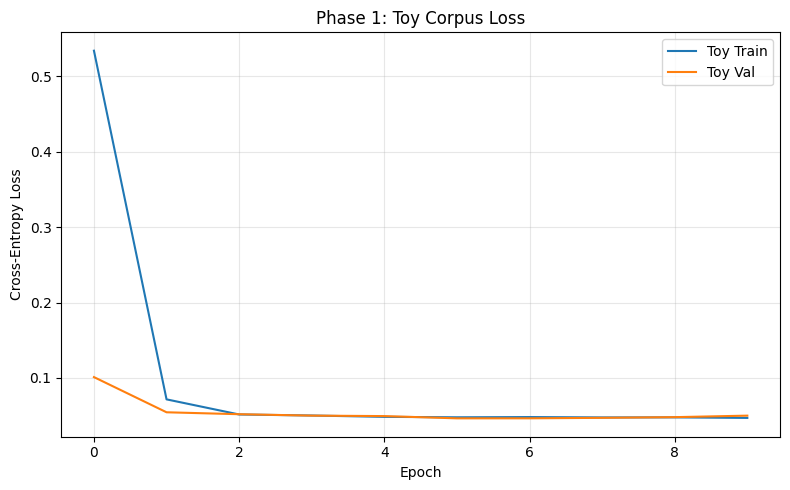

In [50]:
# PHASE 1: TOY CORPUS - PLOTS

plt.figure(figsize=(8, 5))
plt.plot(toy_train_losses, label='Toy Train')
plt.plot(toy_val_losses, label='Toy Val')
plt.title('Phase 1: Toy Corpus Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PHASE 2: REAL GUTENBERG TEXT (~150KB)

In [51]:
# PHASE 2: GUTENBERG TEXT - ALICE IN WONDERLAND (150KB)

print("\n=== PHASE 2: DOWNLOADING GUTENBERG TEXT(ALICE IN WONDERLAND) ===")
alice_url = "https://www.gutenberg.org/files/11/11-0.txt"
response = requests.get(alice_url)
raw_text = response.text

# Clean text
clean_text = re.sub(r'^\*.*?\*PROJECT GUTENBERG\*\s*|^END\*\s*', '', raw_text, flags=re.MULTILINE|re.DOTALL)
clean_text = ''.join(c for c in clean_text if c.isprintable() or c.isspace())
alice_text = clean_text.lower()[:150000]

model_alice, char_alice_ix, ix_alice_char, alice_train_losses, alice_val_losses = train_phase(alice_text, "Alice in Wonderland (150KB)", epochs=15)

# Generating Gutenberg samples
print("\n=== GUTENBERG GENERATIONS (seed: 'alice') ===")
device = next(model_alice.parameters()).device

'''
Temperature effect:
0.7 : Sharper distribution → repetitive but coherent ("hellohellohello...")
1.0 : Original probabilities → balanced
1.2 : Flatter distribution → creative but sometimes gibberish
'''

# Generate samples at different temperatures
for temp in [0.7, 1.0, 1.2]:
    sample = generate(model_alice, char_alice_ix, ix_alice_char, seq_len, device, 'alice', 300, temp)
    # Display samples
    print(f"τ={temp}: {sample[:250]}...")

print("\n COMPLETED PHASE 2 (GUTENBERG TEXT)")


=== PHASE 2: DOWNLOADING GUTENBERG TEXT(ALICE IN WONDERLAND) ===

PHASE Alice in Wonderland (150KB): TRAINING
Corpus: 144696 chars, 50 vocab
Epoch  1 | Train: 1.3618 | Val: 1.7815
Epoch  2 | Train: 1.1755 | Val: 1.8410
Epoch  3 | Train: 1.1437 | Val: 1.8587
Epoch  4 | Train: 1.1307 | Val: 1.8873
Epoch  5 | Train: 1.1246 | Val: 1.8419
Epoch  6 | Train: 1.1227 | Val: 1.9615
Epoch  7 | Train: 1.1226 | Val: 2.0036
Epoch  8 | Train: 1.1241 | Val: 1.8042
Epoch  9 | Train: 1.1283 | Val: 1.9739
Epoch 10 | Train: 1.1319 | Val: 2.0368
Epoch 11 | Train: 1.1387 | Val: 1.9021
Epoch 12 | Train: 1.1452 | Val: 1.8493
Epoch 13 | Train: 1.1557 | Val: 2.0111
Epoch 14 | Train: 1.1679 | Val: 1.9865
Epoch 15 | Train: 1.1836 | Val: 1.9342

=== GUTENBERG GENERATIONS (seed: 'alice') ===
τ=0.7: alice very very were the rugh time to the please very well your hatter dozing at the march hare to speak which shall see it was very melt that alice.

“well, they were ears
wheres of the thought a lobster quadrilled dow

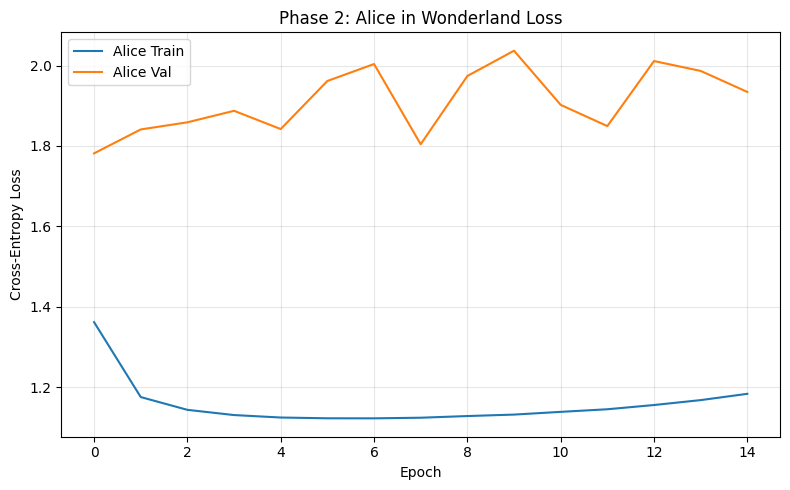

In [52]:
# PHASE 2 : GUTENBERG TEXT PLOTS

plt.figure(figsize=(8, 5))
plt.plot(alice_train_losses, label='Alice Train')
plt.plot(alice_val_losses, label='Alice Val')
plt.title('Phase 2: Alice in Wonderland Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# SAVE OUTPUTS to CSV

'''
out_dir = Path('output')
out_dir.mkdir(exist_ok=True)

with open(out_dir / 'toy_losses.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'val_loss'])
    for i, (tr, va) in enumerate(zip(toy_train_losses, toy_val_losses), 1):
        writer.writerow([i, tr, va])

with open(out_dir / 'alice_losses.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'val_loss'])
    for i, (tr, va) in enumerate(zip(alice_train_losses, alice_val_losses), 1):
        writer.writerow([i, tr, va])

'''

In [53]:
print("\n COMPLETED 2 PHASES (TOY CORPUS & GUTENBERG TEXT)")


 COMPLETED 2 PHASES (TOY CORPUS & GUTENBERG TEXT)


Reflection : When sequence length is increased, the model can capture longer context and longer dependencies, but training becomes slower and harder because gradients must flow through more time steps. Increasing hidden size gives the RNN more capacity to store information and learn richer patterns, but it also increases compute cost and the risk of overfitting. In the generation phase, temperature controls the sampling loop: low values make outputs more deterministic and repetitive, while higher values add diversity but can make text less coherent. These tradeoffs connect directly to the slides: embeddings give each character a dense representation, teacher forcing speeds learning during training, and autoregressive sampling with temperature determines how the model behaves when it generates text on its own.
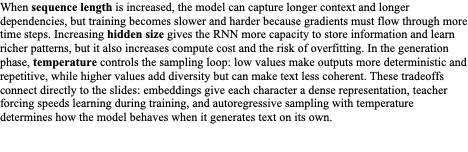
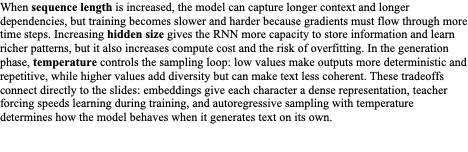
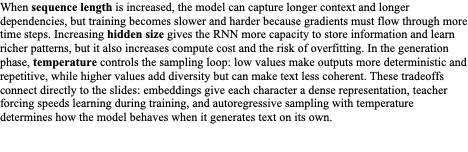
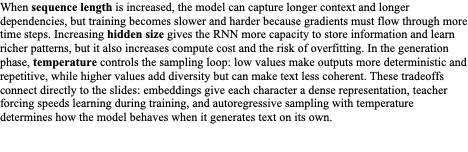